# 실습 2 - Langgraph + Structured_Output + API 연동(Requests)

## `State`
```py
{
    # 초기 입력 데이터 2개. (위도 경도)
    'lat': 37,
    'lon': 126,

    # Open Weather API가 제공한 데이터 그대로 state에 저장
    'weather_data': {...}

    # Structured Output LLM을 사용하여 아래와 같이 구성
    'analysis': {
        'summary': '현재 날씨는 ...,
        'PoP': 37,  # 강수확률(Probability of precipitation)
        'temp': 28,  # 온도
        # 기타 원하는 정보
    }
}
```

## Node
`graph.invoke({'lat': 37, 'lon': 126 })`
1. Start
1. fetch_weather_node
1. analyze_node
1. End (구조화된 데이터)

In [2]:
import os
import requests
from dotenv import load_dotenv
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field

load_dotenv()

OPENWEATEHR_API_KEY = os.getenv("OPENWEATEHR_API_KEY")
asdf = os.getenv('OPENAI_API_KEY')

In [4]:
# Langgraph State
class AnalysisWeather(TypedDict):
    message : str
    lat : float
    lon : float
    weather_data : dict
    analysis : list[str]
    answer : str
# LLM Structured Output 위도 경도
class ExtractedLatLon(BaseModel):
    lat : float = Field(description="유저에게 입력 받은 위도")
    lon : float = Field(description="유저에게 입력 받은 경도")
# LLM Structured Output 최종 날씨 분석 결과
class SturcturedAnalysis(BaseModel):
    summary : str = Field(description='현재 날씨에 대한 요약')
    humidity : int = Field(description='습도')
    temp : float = Field(description='현재 온도')


In [ ]:
#입력 받은 메세지로 위도 경도 추출 노드
def extract_lat_lon(state:AnalysisWeather):

    llm = init_chat_model('openai:gpt-4.1-mini')
    structured_llm = llm.with_structured_output(ExtractedLatLon)

    result = structured_llm.invoke([
        {'role':'system', 'content':'입력받은 메세지를 토대로 api 위도 경도를 반환해줘'},
        {'role':'user', 'content':state['message']},
    ])
    return{'lat':result.lat,'lon':result.lon}

#openweather_api에서 해당 위도경도 날씨 정보 가져오는 노드
def use_openweather_api(state:AnalysisWeather):
    URL = f'https://api.openweathermap.org/data/2.5/weather?lat={state['lat']}&lon={state['lon']}&appid={OPENWEATEHR_API_KEY}'
    res = requests.get(URL)
    return{'weather_data':res.json()}

#입력 받은 API로 날씨분석
def response_analysis(state:AnalysisWeather):
    llm = init_chat_model('openai:gpt-4.1-mini')
    structured_llm = llm.with_structured_output(SturcturedAnalysis)
    system_message = '''너는 입력받은 정보를 바탕으로 현재 위치의 날씨를 분석해주는 AI야.

    '''
    result = structured_llm.invoke([
        {'role':'system','content':system_message},
        {'role':'user','content':f'다음데이터를 분석해줘 : {state['weather_data']}'},
    ])
    return{'analysis':result.model_dump()}

#최종 답변 제출
def make_answer(state:AnalysisWeather):
    llm = init_chat_model('openai:gpt-4.1-mini')
    answer = llm.invoke([
        {'role':'system','content':'입력받은 날씨 자료들을 바탕으로 깔끔하게 정리해서 유저에게 보여줄 내용을 작성해줘'},
        {'role':'user','content':f'''<입력정보>
위도: {state['lat']}
경도: {state['lon']}
날씨정보: {state['weather_data']} 
분석결과: {state['analysis']}'''}
    ])
    return{'answer': answer.content}

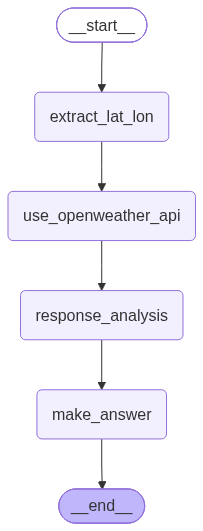

In [7]:
builder = StateGraph(AnalysisWeather)

builder.add_node('extract_lat_lon', extract_lat_lon)
builder.add_node('use_openweather_api', use_openweather_api)
builder.add_node('response_analysis', response_analysis)
builder.add_node('make_answer', make_answer)

builder.add_edge(START, 'extract_lat_lon')
builder.add_edge('extract_lat_lon','use_openweather_api')
builder.add_edge('use_openweather_api','response_analysis')
builder.add_edge('response_analysis', 'make_answer')
builder.add_edge('make_answer', END)

graph = builder.compile()
graph

In [60]:
graph_result = graph.invoke({
    'message':'위도 127 경도 37.5도의 날씨를 알려줘'
})

In [ ]:
print(graph_result['answer'])

현재 위치: 서울 (위도 37.5, 경도 127.0)

날씨 요약:
- 날씨: 구름이 가득한 흐림 (overcast clouds)
- 온도: 약 22도씨 (295.13K)
- 체감 온도: 약 22.86도씨
- 최저/최고 온도: 약 22.0도 / 22.9도씨
- 습도: 100% (매우 높은 습도)
- 기압: 1012 hPa
- 바람: 북동쪽에서 시속 1.54m/s
- 가시거리: 10,000m

현재 서울은 매우 습하고 구름으로 가득한 밤 날씨입니다. 야외 활동 시 참고하시기 바랍니다.